/home/mariia/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Навчання FeedForward (10 нейронів)
Навчання FeedForward (20 нейронів)
Навчання Cascade (20 нейронів)
Навчання Cascade (2x10 нейронів)
Навчання Elman (15 нейронів)
Навчання Elman (3x5 нейронів)

Результати моделювання:
FeedForward (10 нейронів): середня відносна помилка = 1.7381767474840815, R² = 0.22686276958143692
FeedForward (20 нейронів): середня відносна помилка = 1.1520380444479066, R² = 0.6863496860925573
Cascade (20 нейронів): середня відносна помилка = 1.5426693026097913, R² = 0.5781990556835583
Cascade (2x10 нейронів): середня відносна помилка = 0.7124768278167004, R² = 0.8170303376676199
Elman (15 нейронів): середня відносна помилка = 0.46352184510813743, R² = 0.9462986528244267
Elman (3x5 нейронів): середня відносна помилка = 0.6792593338086231, R² = 0.7973589447056406


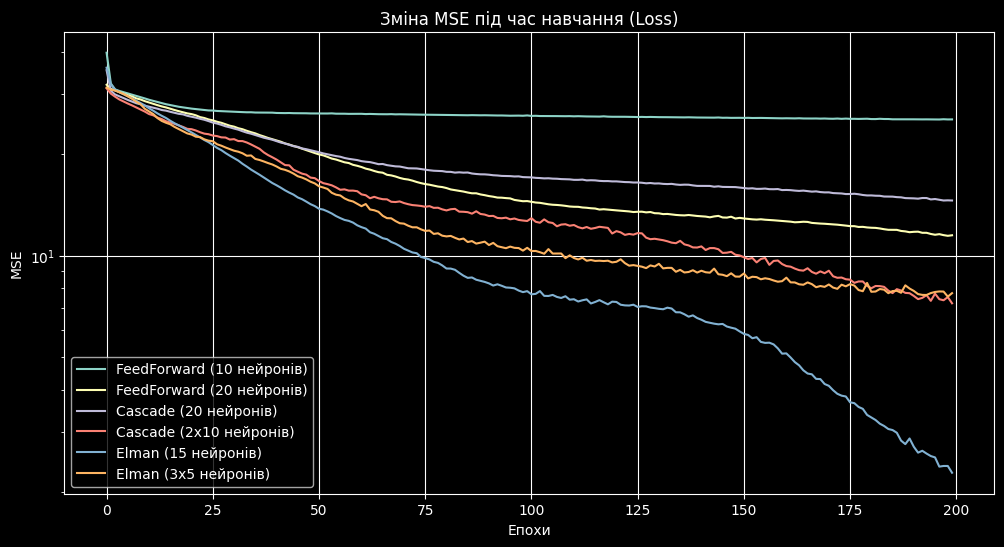

/tmp/ipykernel_131754/1396973267.py:108: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', label="Ідеальна лінія(Y_test = Y_pred)", color="white")


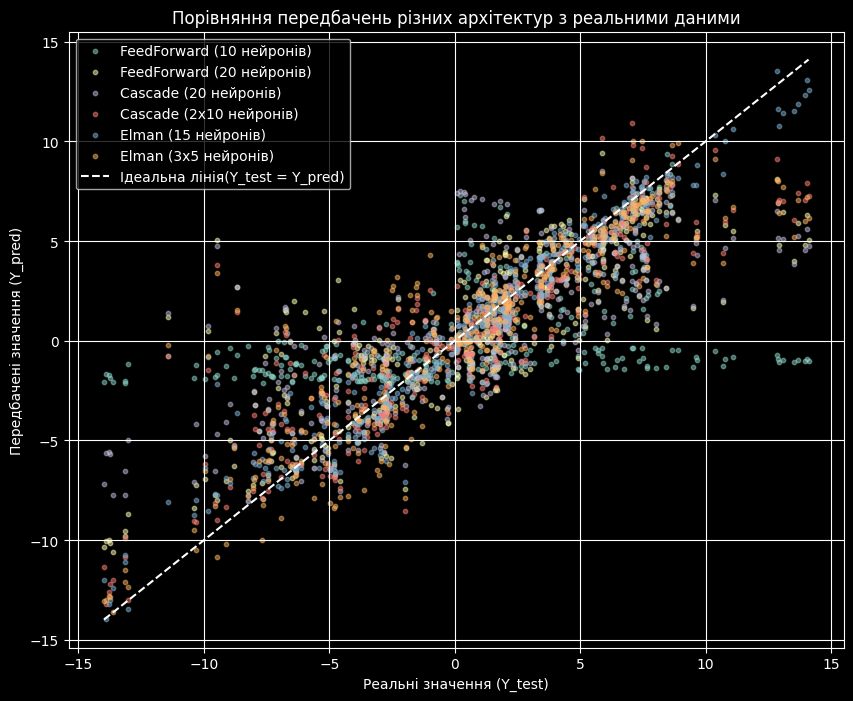

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, Input, concatenate
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# генерація навчальних даних на відрізку [0, 10]
def generate_data(n_samples=2000):
    X = np.random.uniform(0, 10, (n_samples, 2))
    # f(x,y) = x*cos(y) + y*sin(x)
    Y = X[:, 0] * np.cos(X[:, 1]) + X[:, 1] * np.sin(X[:, 0])
    return X, Y

# створення та навчання моделі
def train_and_evaluate(model, X_train, Y_train, X_test, Y_test, epochs=200, batch_size=16):
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_data=(X_test, Y_test))
    Y_pred = model.predict(X_test, verbose=0).flatten()

    # захист від ділення на нуль при розрахунку відносної помилки
    epsilon = 1e-8
    error = np.mean(np.abs((Y_test - Y_pred) / (Y_test + epsilon)))
    r2 = r2_score(Y_test, Y_pred)
    return history, error, Y_pred, r2

# генерація даних та розділення на вибірки
X, Y = generate_data()
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

# підготовка даних для рекурентних мереж (Elman)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# реалізація Cascade-Forward архітектур
# Cascade (1 шар, 20 нейронів)
inputs_c1 = Input(shape=(2,))
hidden_c1 = Dense(20, activation='relu')(inputs_c1)
concat_c1 = concatenate([inputs_c1, hidden_c1])
output_c1 = Dense(1)(concat_c1)
cascade_model_1 = Model(inputs=inputs_c1, outputs=output_c1)

# Cascade (2 шари по 10 нейронів)
inputs_c2 = Input(shape=(2,))
hidden1_c2 = Dense(10, activation='relu')(inputs_c2)
concat1_c2 = concatenate([inputs_c2, hidden1_c2])
hidden2_c2 = Dense(10, activation='relu')(concat1_c2)
concat2_c2 = concatenate([inputs_c2, hidden1_c2, hidden2_c2])
output_c2 = Dense(1)(concat2_c2)
cascade_model_2 = Model(inputs=inputs_c2, outputs=output_c2)

# ініціалізація всіх необхідних моделей
models = {
    "FeedForward (10 нейронів)": Sequential([Input(shape=(2,)), Dense(10, activation='relu'), Dense(1)]),
    "FeedForward (20 нейронів)": Sequential([Input(shape=(2,)), Dense(20, activation='relu'), Dense(1)]),
    "Cascade (20 нейронів)": cascade_model_1,
    "Cascade (2x10 нейронів)": cascade_model_2,
    "Elman (15 нейронів)": Sequential([SimpleRNN(15, activation='relu', input_shape=(2, 1)), Dense(1)]),
    "Elman (3x5 нейронів)": Sequential([
        SimpleRNN(5, activation='relu', return_sequences=True, input_shape=(2, 1)),
        SimpleRNN(5, activation='relu', return_sequences=True),
        SimpleRNN(5, activation='relu'),
        Dense(1)
    ])
}

# навчання та оцінка моделей
errors = {}
predictions = {}
r2_scores = {}
histories = {}

for name, model in models.items():
    print(f"Навчання {name}")
    if "Elman" in name:
        history, error, Y_pred, r2 = train_and_evaluate(model, X_train_rnn, Y_train, X_test_rnn, Y_test)
    else:
        history, error, Y_pred, r2 = train_and_evaluate(model, X_train, Y_train, X_test, Y_test)

    errors[name] = error
    predictions[name] = Y_pred
    r2_scores[name] = r2
    histories[name] = history.history['loss']

# виведення метрик
print("\nРезультати моделювання:")
for name in models.keys():
    print(f"{name}: середня відносна помилка = {errors[name]}, R² = {r2_scores[name]}")

# візуалізація графіка функції втрат
plt.figure(figsize=(12, 6))
for name, loss in histories.items():
    plt.plot(loss, label=name)
plt.title("Зміна MSE під час навчання (Loss)")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

# візуалізація передбачень
plt.figure(figsize=(10, 8))
for name, Y_pred in predictions.items():
    plt.scatter(Y_test, Y_pred, label=name, alpha=0.5, s=10)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', label="Ідеальна лінія(Y_test = Y_pred)", color="white")
plt.xlabel("Реальні значення (Y_test)")
plt.ylabel("Передбачені значення (Y_pred)")
plt.legend()
plt.title("Порівняння передбачень різних архітектур з реальними даними")
plt.grid(True)
plt.show()

150 епох навчання:

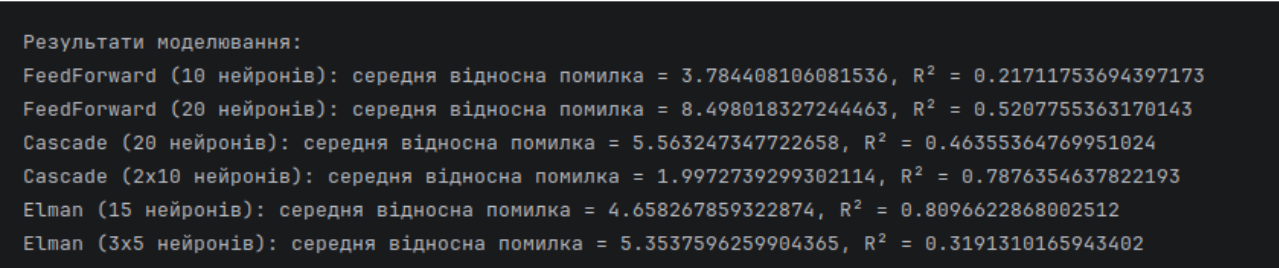

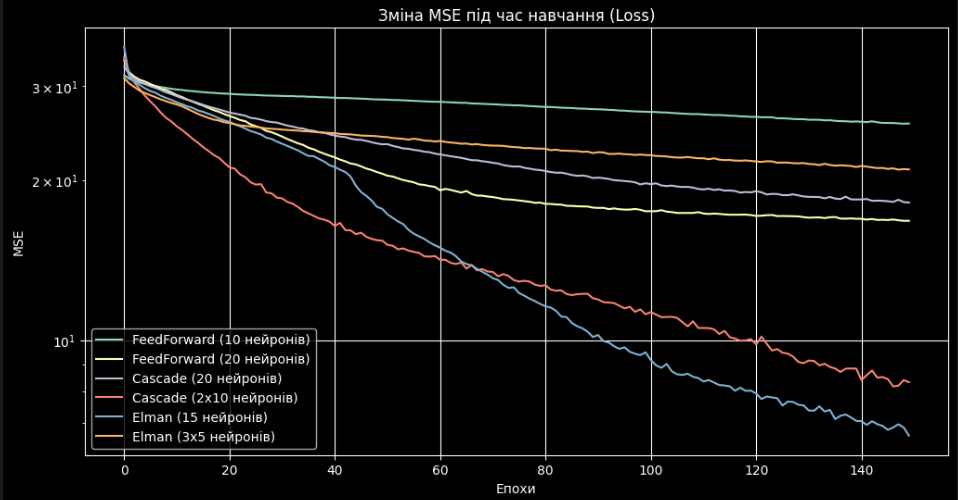

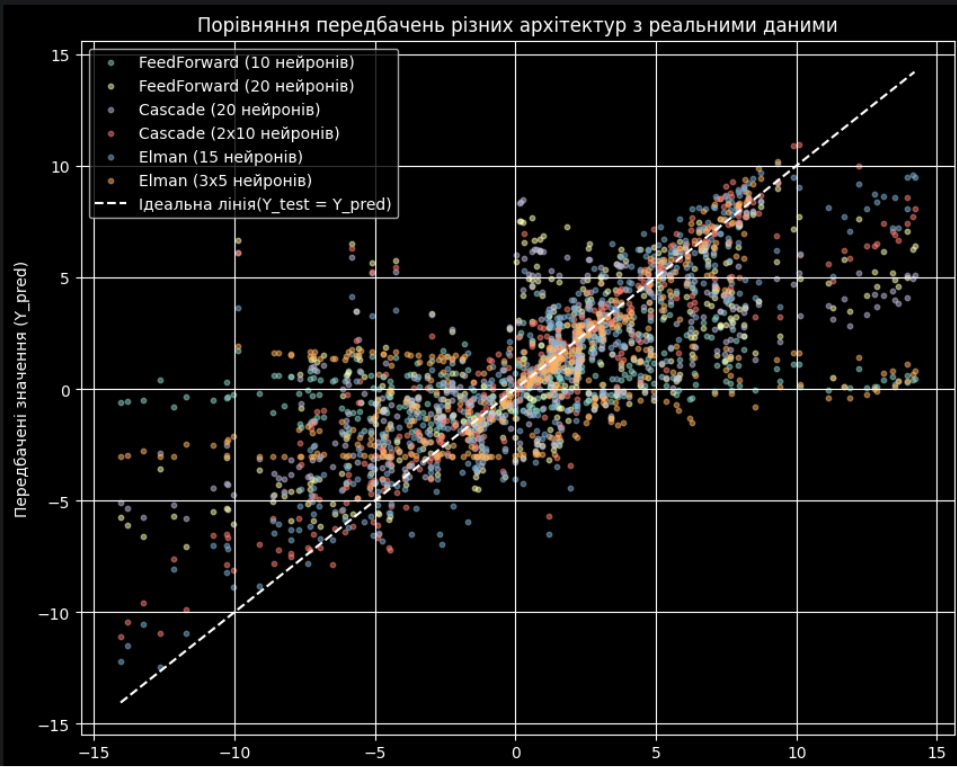